# Autoencoder — AE v5

**Input:** `nominal_scaled`, `kategori_detail_encoded_scaled`, `hour_sin_scaled`, `hour_cos_scaled`, `nominal_z_user_kat_scaled`

In [7]:
import os
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

DATA_DIR  = '../../../data/new'
MODEL_DIR = '../../../model/03_ae'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(tf.config.list_physical_devices())

TensorFlow : 2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Load Data

In [8]:
meta = joblib.load(f'{MODEL_DIR}/preprocessing_meta.pkl')
SCALED_COLS = meta['scaled_cols']

df_train     = pd.read_csv(f'{DATA_DIR}/pre_train.csv')
df_threshold = pd.read_csv(f'{DATA_DIR}/pre_threshold.csv', parse_dates=['timestamp'])

X_train = df_train[SCALED_COLS].values.astype(np.float32)
INPUT_DIM = X_train.shape[1]

print(f"X_train   : {X_train.shape}")
print(f"threshold : {df_threshold.shape}")
print(f"Input dim : {INPUT_DIM}")

X_train   : (176459, 5)
threshold : (45110, 17)
Input dim : 5


## Arsitektur

```
Input(5) → Dense(16) → Dense(8) → Dense(2) [bottleneck]
         → Dense(8)  → Dense(16) → Dense(5)
```

**Loss: MAE**


In [9]:
def build_autoencoder(input_dim):
    inp     = Input(shape=(input_dim,))
    x       = Dense(32, activation='relu')(inp)
    x       = Dense(16,  activation='relu')(x)
    encoded = Dense(4,  activation='relu')(x)
    x       = Dense(16,  activation='relu')(encoded)
    x       = Dense(32, activation='relu')(x)
    out     = Dense(input_dim, activation='linear')(x)
    model   = Model(inputs=inp, outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mae')
    return model

autoencoder = build_autoencoder(INPUT_DIM)
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,577 (6.16 KB)

 Trainable params: 1,577 (6.16 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,    
        min_lr=1e-4,     
        verbose=1
    ),
    ModelCheckpoint(f'{MODEL_DIR}/autoencoder.keras', monitor='val_loss', save_best_only=True, verbose=0),
]

history = autoencoder.fit(
    X_train, X_train,
    epochs=150,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

print(f"Best val_loss : {min(history.history['val_loss']):.6f}")

Epoch 1/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 1s 629us/step - loss: 0.2859 - val_loss: 0.1834 - learning_rate: 0.0010
Epoch 2/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - loss: 0.1537 - val_loss: 0.1233 - learning_rate: 0.0010
Epoch 3/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - loss: 0.1016 - val_loss: 0.0781 - learning_rate: 0.0010
Epoch 4/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - loss: 0.0769 - val_loss: 0.0705 - learning_rate: 0.0010
Epoch 5/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - loss: 0.0716 - val_loss: 0.0678 - learning_rate: 0.0010
Epoch 6/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 438us/step - loss: 0.0686 - val_loss: 0.0615 - learning_rate: 0.0010
Epoch 7/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step - loss: 0.0667 - val_loss: 0.0635 - learning_rate: 0.0010
Epoch 8/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 0.0651 - val_loss: 0.0600 - learning_rate: 0.0010
Epoch 9/150
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 0.0638 - val_loss: 0.0604 - learn

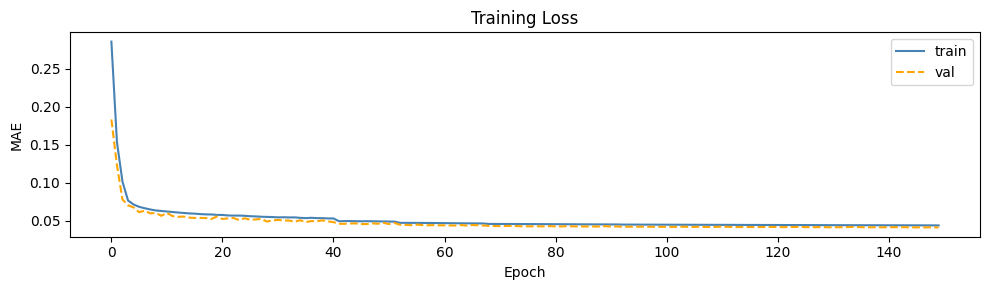

In [11]:
plt.figure(figsize=(10, 3))
plt.plot(history.history['loss'],     label='train', color='steelblue')
plt.plot(history.history['val_loss'], label='val',   color='orange', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Threshold per User per Kategori

Fit pada **threshold data** (Bulan 5 — normal). Threshold = persentil 95 MAE per `(id_user, kategori_detail)`.

In [12]:
autoencoder = tf.keras.models.load_model(    f'{MODEL_DIR}/autoencoder.keras', compile=False)
X_thr     = df_threshold[SCALED_COLS].values.astype(np.float32)
X_thr_rec = autoencoder.predict(X_thr, verbose=0)
mae_thr = np.abs(X_thr - X_thr_rec).mean(axis=1)
df_threshold = df_threshold.copy()
df_threshold['mae'] = mae_thr
threshold_user_kat = (    df_threshold.groupby(['id_user', 'kategori_detail'])['mae']    .quantile(0.90)    .rename('threshold')    .reset_index())
threshold_kat = (    df_threshold.groupby('kategori_detail')['mae']    .quantile(0.90)    .rename('threshold')    .to_dict())
print(f"User×kategori combinations : {len(threshold_user_kat)}")
print(f"Kategori fallback          : {len(threshold_kat)}")
print(threshold_user_kat.head(10).to_string(index=False))

User×kategori combinations : 4013
Kategori fallback          : 10
id_user             kategori_detail    threshold
USR-001           F&B dan Nongkrong 1.193792e-02
USR-001 Groceries & Kebutuhan Pokok 3.083199e-02
USR-001         Hiburan & Langganan 9.496116e-02
USR-001       Investasi & Finansial 1.527743e+13
USR-001  Kesehatan & Perawatan Diri 7.011572e-02
USR-001                Transfer P2P 4.412114e-02
USR-001                Transportasi 2.898306e-02
USR-002    Belanja Online & Fashion 1.403377e-01
USR-002           F&B dan Nongkrong 1.740552e-02
USR-002 Groceries & Kebutuhan Pokok 1.516027e-02


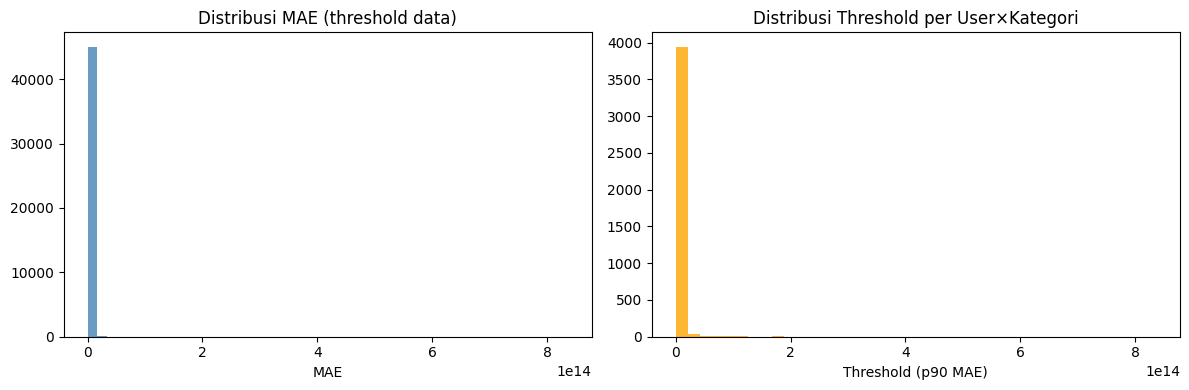

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mae_thr, bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('Distribusi MAE (threshold data)')
axes[0].set_xlabel('MAE')

axes[1].hist(threshold_user_kat['threshold'], bins=40, color='orange', alpha=0.8)
axes[1].set_title('Distribusi Threshold per User×Kategori')
axes[1].set_xlabel('Threshold (p90 MAE)')

plt.tight_layout()
plt.show()

## Validasi pada Test Data

Evaluasi model pada fase test menggunakan kondisi dua syarat:
prediksi anomali hanya aktif jika **MAE > threshold** sekaligus **nominal > mean_nominal** user di kategori tersebut (baseline dari threshold data).

In [14]:
df_test_val = pd.read_csv(f'{DATA_DIR}/pre_test.csv', parse_dates=['timestamp'])
X_test_val  = df_test_val[SCALED_COLS].values.astype(np.float32)
X_test_rec  = autoencoder.predict(X_test_val, verbose=0)
mae_test    = np.abs(X_test_val - X_test_rec).mean(axis=1)
df_test_val['mae'] = mae_test
threshold_dict = {    (row['id_user'], row['kategori_detail']): row['threshold']    for _, row in threshold_user_kat.iterrows()}
_median_thr = float(np.median(list(threshold_dict.values())))
df_test_val['threshold'] = df_test_val.apply(    lambda r: threshold_dict.get(        (r['id_user'], r['kategori_detail']),        threshold_kat.get(r['kategori_detail'], _median_thr)    ), axis=1)
user_cat_mean_nominal = (    df_threshold.groupby(['id_user', 'kategori_detail'])['nominal']    .mean()    .rename('mean_nominal')    .reset_index())
cat_mean_nominal = (    df_threshold.groupby('kategori_detail')['nominal']    .mean()    .to_dict())
df_test_val = df_test_val.merge(user_cat_mean_nominal, on=['id_user', 'kategori_detail'], how='left')
df_test_val['mean_nominal'] = df_test_val['mean_nominal'].fillna(    df_test_val['kategori_detail'].map(cat_mean_nominal))
df_test_val['pred_anomali'] = (    (df_test_val['mae'] > df_test_val['threshold']) &    (df_test_val['nominal'] > df_test_val['mean_nominal'])).astype(int)
y_true_val = df_test_val['label_anomali'].values.astype(int)
print(classification_report(y_true_val, df_test_val['pred_anomali'],                             target_names=['Normal', 'Anomali']))

              precision    recall  f1-score   support

      Normal       0.99      0.89      0.93     39884
     Anomali       0.47      0.90      0.61      4431

    accuracy                           0.89     44315
   macro avg       0.73      0.89      0.77     44315
weighted avg       0.94      0.89      0.90     44315



## Simpan

In [15]:
threshold_dict = {    (row['id_user'], row['kategori_detail']): row['threshold']    for _, row in threshold_user_kat.iterrows()}
joblib.dump({    'threshold_user_kat' : threshold_dict,    'threshold_kat'      : threshold_kat,    'scaled_cols'        : SCALED_COLS,}, f'{MODEL_DIR}/model_meta.pkl')
print(f"autoencoder.keras  → {MODEL_DIR}")
print(f"model_meta.pkl     → {MODEL_DIR}")

autoencoder.keras  → ../../../model/03_ae
model_meta.pkl     → ../../../model/03_ae
